In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df =  pd.read_csv('datasets\\Family Income and Expenditure.csv')
# Filter Region IVA - CALABARZON
cal = df[df['Region'].str.contains("IVA", case=False, na=False)].copy()
iva = df[df["Region"] == "IVA"]

cal.head()

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
2520,118410,IVA - CALABARZON,71019,Wage/Salaries,0,27477,24160,10688,10280,1090,...,0,0,0,0,0,2,0,0,0,0
2521,151380,IVA - CALABARZON,80889,Wage/Salaries,0,26307,22600,14007,6578,1790,...,0,1,0,0,0,2,0,0,0,0
2522,282373,IVA - CALABARZON,112023,Wage/Salaries,0,32817,29250,18110,13496,850,...,0,1,0,0,0,2,1,0,0,0
2523,146190,IVA - CALABARZON,77491,Wage/Salaries,0,20390,14313,15072,9682,1310,...,0,0,0,0,0,1,0,0,0,1
2524,95530,IVA - CALABARZON,67688,Other sources of Income,0,28642,26000,13429,5024,850,...,0,0,0,0,0,1,0,0,0,0


# Descriptive Analysis

# 📊 1. Distribution of Household Income in CALABARZON

This section shows how household incomes are spread across the region.

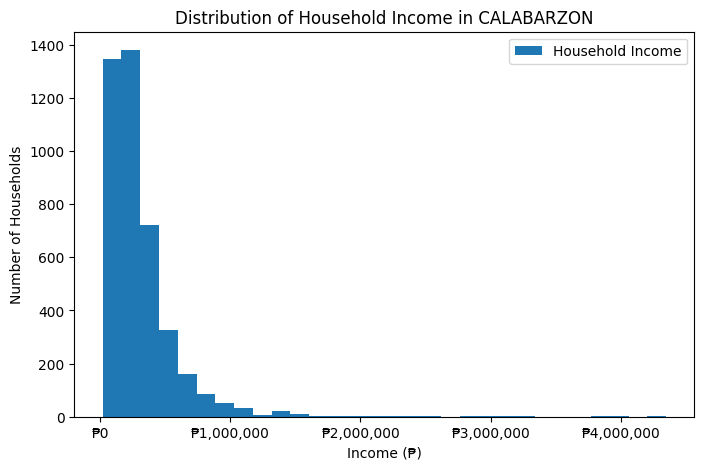

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))
plt.hist(cal['Total Household Income'], bins=30, label="Household Income")
plt.title("Distribution of Household Income in CALABARZON")
plt.xlabel("Income (₱)")
plt.ylabel("Number of Households")
plt.legend()

# Format x-axis with commas
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"₱{int(x):,}"))

plt.show()


# **Insights**
## 1. **Household income in CALABARZON is unevenly distributed.**  
   ### The histogram shows that most households fall within the lower income levels, while a smaller number belong to higher-income groups.

## 2. **The distribution is right-skewed, revealing income inequality.**  
   ### A few high-income households significantly raise the mean income, while most households earn below the regional average.


# 📊 2. Average Expenditure Composition in CALABARZON

This section compares major spending categories such as food, utilities, transport, housing, and education.

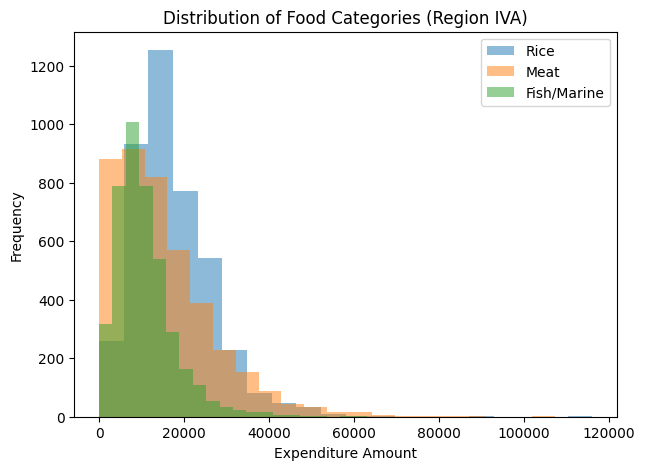

In [38]:
fish_col = [c for c in cal.columns if "fish" in c.lower()][0]

plt.figure(figsize=(7,5))
plt.hist(cal["Total Rice Expenditure"], bins=20, alpha=0.5, label="Rice")
plt.hist(cal["Meat Expenditure"], bins=20, alpha=0.5, label="Meat")
plt.hist(cal[fish_col], bins=20, alpha=0.5, label="Fish/Marine")
plt.xlabel("Expenditure Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Food Categories (Region IVA)")
plt.legend()
plt.show()


# **Insights**
## 3. **Food is the largest spending category among CALABARZON households.**  
   ### The bar chart clearly shows that food expenditure surpasses all other categories.

## 4. **Utilities and transportation form the biggest non-food expenses.**  
  ### Electricity, water, and transport consume a significant share of household budgets.

# 📊 3. Food Expenditure Breakdown in CALABARZON

This section visualizes how households distribute their food spending across different categories.



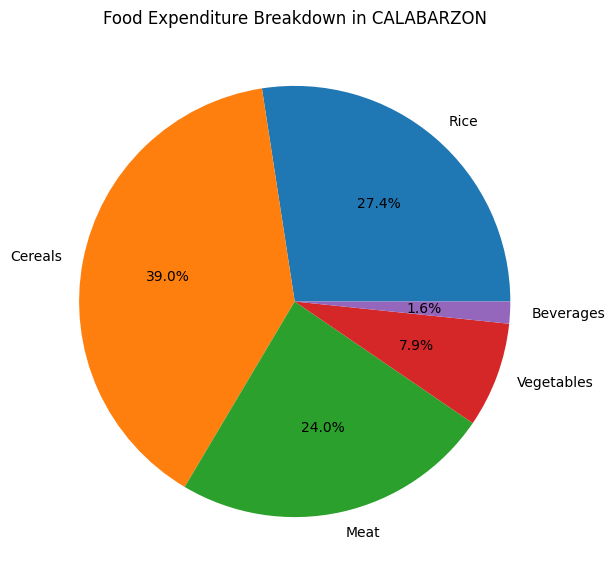

In [30]:
food_profile = {
    "Rice": cal["Total Rice Expenditure"].mean(),
    "Cereals": cal["Bread and Cereals Expenditure"].mean(),
    "Meat": cal["Meat Expenditure"].mean(),
    "Vegetables": cal["Vegetables Expenditure"].mean(),
    "Beverages": cal["Alcoholic Beverages Expenditure"].mean()
}

plt.figure(figsize=(7,7))
plt.pie(food_profile.values(), labels=food_profile.keys(), autopct='%1.1f%%')
plt.title("Food Expenditure Breakdown in CALABARZON")
plt.show()


# **Insight**
## 5. **Cereals lead food spending among CALABARZON families, followed by rice and meat.**  
  ### The pie chart shows cereals as the top food expense, making up 39% of household food budgets. Rice and meat follow closely, highlighting the region’s reliance on staple grains and protein-rich meals.

<H1>DIAGNOSTIC</H1>

<H2>Why Some CALABARZON Households Allocate More Income to Utilities?</H2>

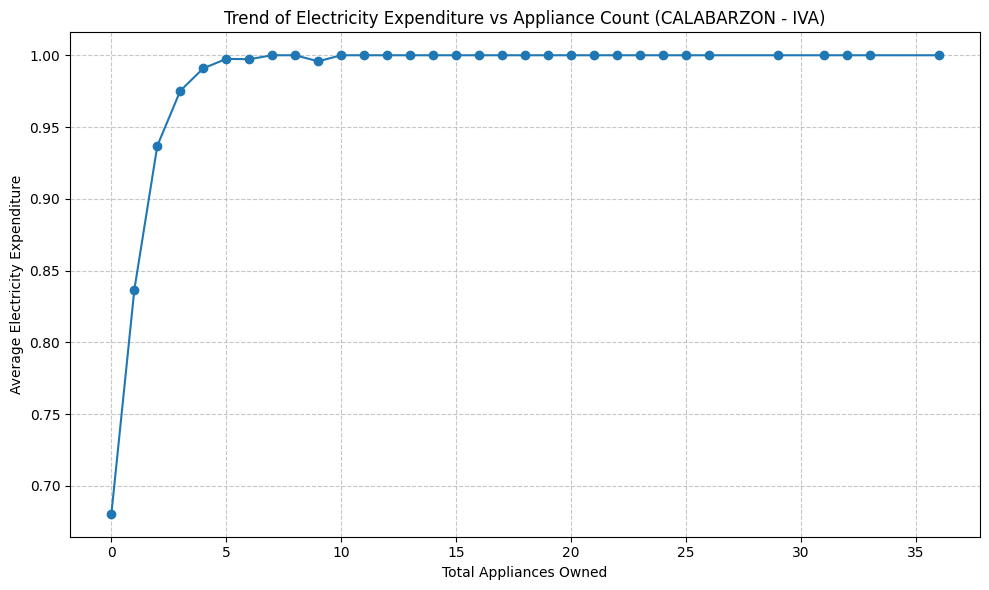

In [3]:
filtered = df[df['Region'] == 'IVA - CALABARZON'].copy()

appliance_cols = [
    'Number of Television',
    'Number of CD/VCD/DVD',
    'Number of Component/Stereo set',
    'Number of Refrigerator/Freezer',
    'Number of Washing Machine',
    'Number of Airconditioner',
    'Number of Car, Jeep, Van',
    'Number of Landline/wireless telephones',
    'Number of Cellular phone',
    'Number of Personal Computer',
    'Number of Stove with Oven/Gas Range',
    'Number of Motorized Banca',
    'Number of Motorcycle/Tricycle'
]

for col in appliance_cols:
    filtered[col] = pd.to_numeric(filtered[col], errors='coerce').fillna(0)

filtered['Electricity'] = pd.to_numeric(filtered['Electricity'], errors='coerce').fillna(0)

filtered['Total Appliances'] = filtered[appliance_cols].sum(axis=1)

grouped = filtered.groupby('Total Appliances')['Electricity'].mean()

plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o')

plt.xlabel("Total Appliances Owned")
plt.ylabel("Average Electricity Expenditure")
plt.title("Trend of Electricity Expenditure vs Appliance Count (CALABARZON - IVA)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<H2>INSIGHT 6</H2>
<p>
Electricity expenditure in CALABARZON increases sharply when households acquire their first few essential appliances (approximately 1–4 items).  
</p>

<H2>Causes of High Transportation Spending in CALABARZON</H2>

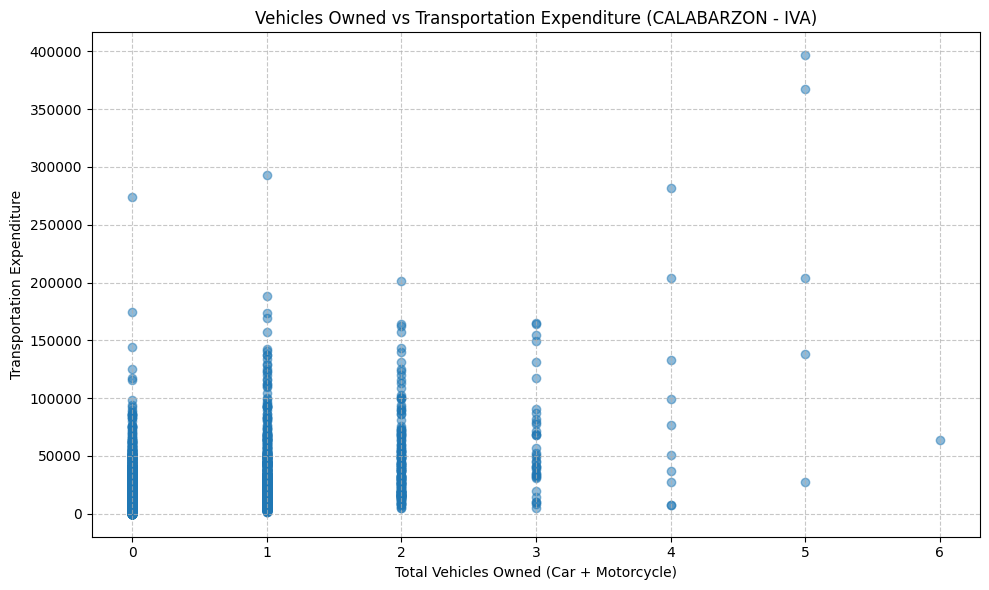

In [4]:
filtered = df[df['Region'] == 'IVA - CALABARZON'].copy()

for col in [
    'Transportation Expenditure',
    'Total Household Income',
    'Number of Motorcycle/Tricycle',
    'Number of Car, Jeep, Van'
]:
    filtered[col] = pd.to_numeric(filtered[col], errors='coerce').fillna(0)

filtered['Total Vehicles'] = (
    filtered['Number of Motorcycle/Tricycle'] +
    filtered['Number of Car, Jeep, Van']
)


plt.figure(figsize=(10, 6))

plt.scatter(
    filtered['Total Vehicles'],
    filtered['Transportation Expenditure'],
    alpha=0.5
)

plt.xlabel("Total Vehicles Owned (Car + Motorcycle)")
plt.ylabel("Transportation Expenditure")
plt.title("Vehicles Owned vs Transportation Expenditure (CALABARZON - IVA)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<H2>INSIGHT 7</H2>
<p>Transport spending in CALABARZON increases primarily due to vehicle ownership, especially when households own 2 or more vehicles.
Even households with no vehicles still spend heavily due to commuting costs.</p>

<h2>Why Some Households Have More Assets Than Others (CALABARZON)?</h2>

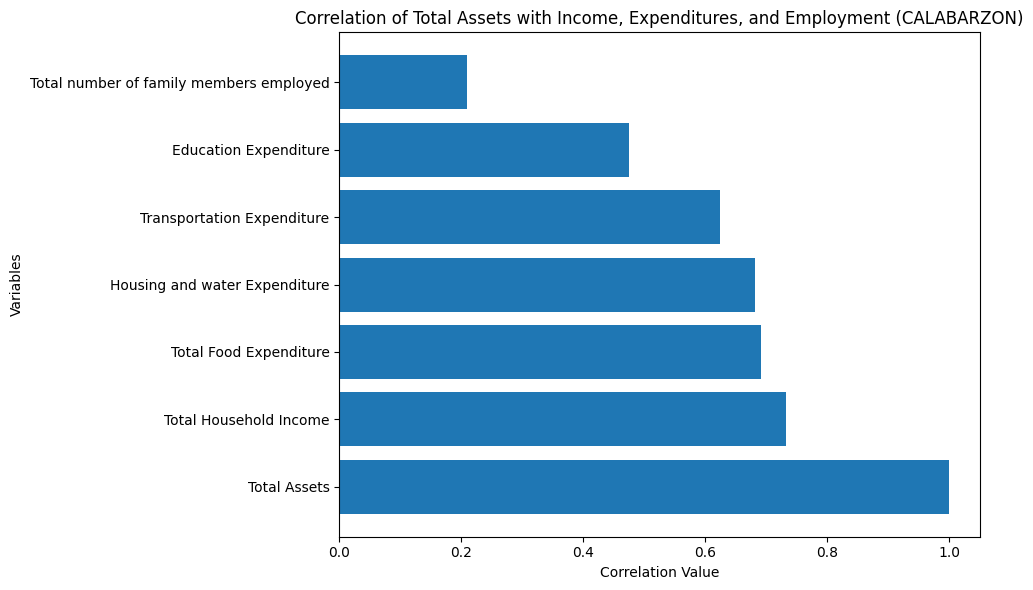

In [5]:
filtered = df[df['Region'] == 'IVA - CALABARZON'].copy()

asset_cols = [
    'Number of Television',
    'Number of CD/VCD/DVD',
    'Number of Component/Stereo set',
    'Number of Refrigerator/Freezer',
    'Number of Washing Machine',
    'Number of Airconditioner',
    'Number of Car, Jeep, Van',
    'Number of Landline/wireless telephones',
    'Number of Cellular phone',
    'Number of Personal Computer',
    'Number of Stove with Oven/Gas Range',
    'Number of Motorized Banca',
    'Number of Motorcycle/Tricycle'
]

for col in asset_cols:
    filtered[col] = pd.to_numeric(filtered[col], errors='coerce').fillna(0)

filtered['Total Assets'] = filtered[asset_cols].sum(axis=1)

numeric_cols = [
    'Total Household Income',
    'Total number of family members employed',
    'Total Food Expenditure',
    'Housing and water Expenditure',
    'Transportation Expenditure',
    'Education Expenditure',
    'Miscellaneous Goods and Services Expenditure'
]

for col in numeric_cols:
    filtered[col] = pd.to_numeric(filtered[col], errors='coerce')

filtered['Main Source of Income Encoded'] = filtered['Main Source of Income'].astype('category').cat.codes

corr_cols = [
    'Total Assets',
    'Total Household Income',
    'Total number of family members employed',
    'Total Food Expenditure',
    'Housing and water Expenditure',
    'Transportation Expenditure',
    'Education Expenditure'
]

corr_matrix = filtered[corr_cols].corr()

corr_with_assets = corr_matrix['Total Assets'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(corr_with_assets.index, corr_with_assets.values)
plt.title("Correlation of Total Assets with Income, Expenditures, and Employment (CALABARZON)")
plt.xlabel("Correlation Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

<H2>INSIGHT 8</H2>
<P>Number of Family Members Employed has small correlation (≈0.25) This still matters but is not a major factor. More employed members slightly more assets. </P>
<h2>INSIGHT 9</h2>
<P>Total Household Income has the strongest positive correlation (≈0.75–0.80). Households with higher income tend to own more appliances, gadgets, and vehicles.</P>

<H1>PREDICTIVE</H1>

R² Score: 0.8927483298928414
MAE: 42589.203497398965


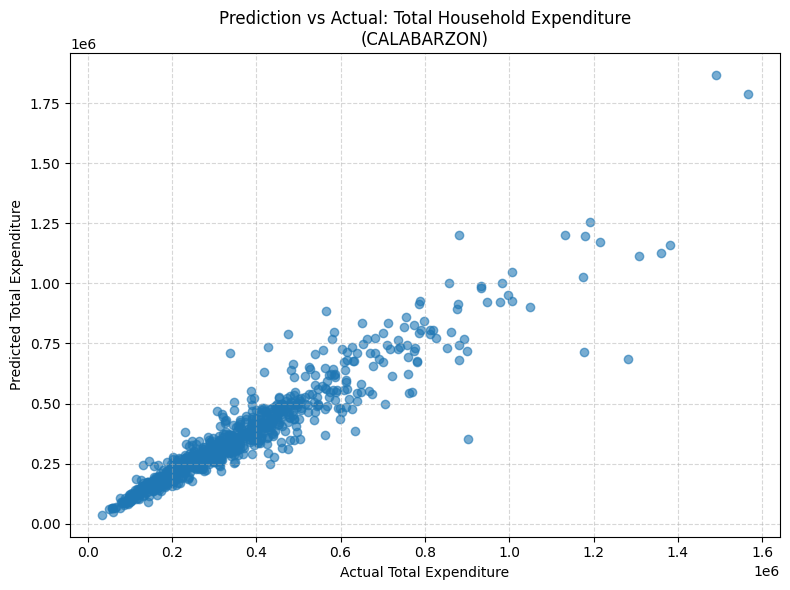

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

filtered = df[df['Region'] == 'IVA - CALABARZON'].copy()

exp_cols = [
    'Total Food Expenditure',
    'Bread and Cereals Expenditure',
    'Total Rice Expenditure',
    'Meat Expenditure',
    'Total Fish and  marine products Expenditure',
    'Fruit Expenditure',
    'Vegetables Expenditure',
    'Restaurant and hotels Expenditure',
    'Alcoholic Beverages Expenditure',
    'Tobacco Expenditure',
    'Clothing, Footwear and Other Wear Expenditure',
    'Housing and water Expenditure',
    'Imputed House Rental Value',
    'Medical Care Expenditure',
    'Transportation Expenditure',
    'Communication Expenditure',
    'Education Expenditure',
    'Miscellaneous Goods and Services Expenditure',
    'Special Occasions Expenditure',
    'Crop Farming and Gardening expenses'
]

for col in exp_cols:
    filtered[col] = pd.to_numeric(filtered[col], errors='coerce').fillna(0)

filtered["Total Expenditure"] = filtered[exp_cols].sum(axis=1)

asset_cols = [
    'Number of Television',
    'Number of CD/VCD/DVD',
    'Number of Component/Stereo set',
    'Number of Refrigerator/Freezer',
    'Number of Washing Machine',
    'Number of Airconditioner',
    'Number of Car, Jeep, Van',
    'Number of Landline/wireless telephones',
    'Number of Cellular phone',
    'Number of Personal Computer',
    'Number of Stove with Oven/Gas Range',
    'Number of Motorized Banca',
    'Number of Motorcycle/Tricycle'
]

for col in asset_cols:
    filtered[col] = pd.to_numeric(filtered[col], errors='coerce').fillna(0)

filtered["Total Assets"] = filtered[asset_cols].sum(axis=1)

filtered['Total Household Income'] = pd.to_numeric(filtered['Total Household Income'], errors='coerce')
filtered['Total Number of Family members'] = pd.to_numeric(filtered['Total Number of Family members'], errors='coerce')
filtered['Agricultural Household indicator'] = pd.to_numeric(filtered['Agricultural Household indicator'], errors='coerce')

# Encode category
filtered["Main Source of Income Encoded"] = filtered["Main Source of Income"].astype("category").cat.codes

# Predictor variables
X = filtered[[
    'Total Household Income',
    'Total Food Expenditure',
    'Total Number of Family members',
    'Total Assets',
    'Main Source of Income Encoded',
    'Agricultural Household indicator'
]]

y = filtered["Total Expenditure"]

X = X.fillna(0)
y = y.fillna(0)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Total Expenditure")
plt.ylabel("Predicted Total Expenditure")
plt.title("Prediction vs Actual: Total Household Expenditure\n(CALABARZON)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<h2>INSIGHT 10</h2>
<P>The model achieves an R² of 0.89, which means 89% of the variation in Total Household Expenditure can be explained by income, household characteristics, and asset ownership.</P>